# Task 1: Data Exploration & Enrichment (Refactored — Week 12)

> **Week 12 engineering update:** this notebook now calls the reusable,
> tested functions in `src/data_loader.py` instead of repeating the same
> pandas logic inline. The corresponding unit tests live in
> `tests/test_data_loader.py` (see Second Interim engineering log).
> Original Week 11 analysis and conclusions are unchanged — only the
> *implementation* moved into `src/`.

In [1]:
# Setup: make the project's src/ package importable from notebooks/
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.data_loader import (
    load_raw_dataset,
    get_observations,
    get_events,
    assess_data_quality,
    save_processed_dataset,
)
from src.event_model import merge_events_with_impacts
from src.config import RAW_EXCEL_FILE, REFERENCE_CODES_FILE

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
plt.style.use("ggplot")

## 1. Data Loading

All three raw files are loaded through a single, tested function: `load_raw_dataset()`.

In [2]:
df, impact_links, reference = load_raw_dataset(
    excel_file=RAW_EXCEL_FILE,
    reference_codes_file=REFERENCE_CODES_FILE,
)

print("Main Dataset Shape:", df.shape)
print("Impact Links Shape:", impact_links.shape)
print("Reference Codes Shape:", reference.shape)

Main Dataset Shape: (43, 34)
Impact Links Shape: (14, 35)
Reference Codes Shape: (71, 4)


In [3]:
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [4]:
reference.head(20)

,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All
5,record_type,forecast,Predicted future value,All
6,category,product_launch,New product or service introduced,event
7,category,market_entry,New competitor enters market,event
8,category,market_exit,Competitor leaves market,event
9,category,policy,Government strategy or regulatory framework,event


## 2. Schema Understanding

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            43 non-null     str           
 1   record_type          43 non-null     str           
 2   category             10 non-null     str           
 3   pillar               33 non-null     str           
 4   indicator            43 non-null     str           
 5   indicator_code       43 non-null     str           
 6   indicator_direction  33 non-null     str           
 7   value_numeric        33 non-null     float64       
 8   value_text           10 non-null     str           
 9   value_type           43 non-null     str           
 10  unit                 33 non-null     str           
 11  observation_date     43 non-null     datetime64[us]
 12  period_start         10 non-null     datetime64[us]
 13  period_end           10 non-null     datetime64[

In [6]:
print(df.columns.tolist())

['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


## 3. Dataset Exploration

### Record types

In [7]:
df["record_type"].value_counts()

record_type
observation    30
event          10
target          3
Name: count, dtype: int64

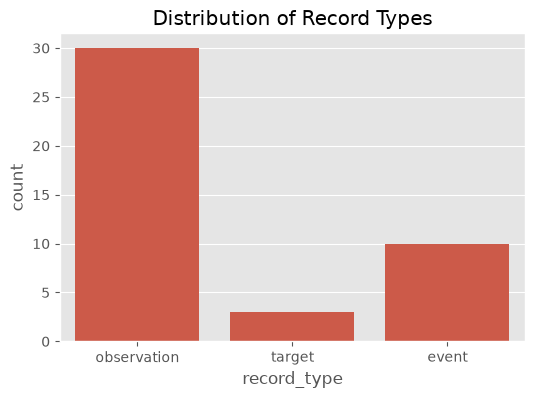

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="record_type")
plt.title("Distribution of Record Types")
plt.show()

In [9]:
print("Pillars:")
print(df["pillar"].value_counts(dropna=False))
print("\nSource types:")
print(df["source_type"].value_counts(dropna=False))
print("\nConfidence:")
print(df["confidence"].value_counts(dropna=False))

Pillars:
pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

Source types:
source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

Confidence:
confidence
high      40
medium     3
Name: count, dtype: int64


## 4. Observation Analysis

`get_observations()` filters to `record_type == "observation"` and parses `observation_date` — replaces the two duplicated filter/parse cells from the Week 11 version.

In [10]:
observations = get_observations(df)
print("Number of observations:", observations.shape[0])
print("Unique indicators:", observations["indicator_code"].nunique())
print("Date range:", observations["observation_date"].min(), "to", observations["observation_date"].max())

Number of observations: 30
Unique indicators: 19
Date range: 2014-12-31 00:00:00 to 2025-12-31 00:00:00


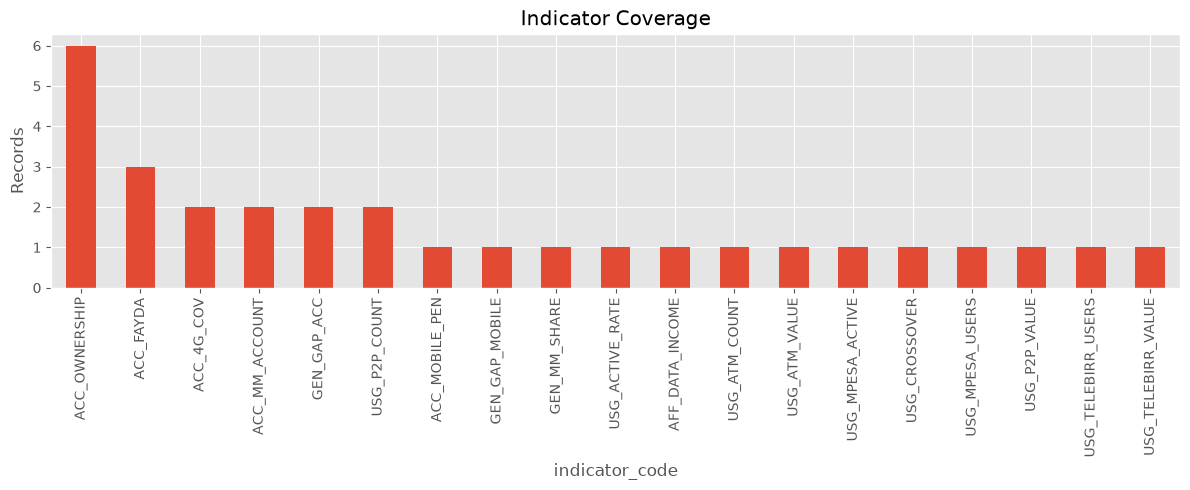

In [11]:
coverage = (
    observations
    .groupby("indicator_code")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
coverage.plot(kind="bar")
plt.ylabel("Records")
plt.title("Indicator Coverage")
plt.tight_layout()
plt.show()

## 5. Event Analysis

`get_events()` filters and sorts events by date — replaces the equivalent Week 11 cells.

In [12]:
events = get_events(df)
events[["record_id", "category", "observation_date", "notes"]]

,record_id,category,observation_date,notes
33,EVT_0001,product_launch,2021-05-17,NaN
41,EVT_0009,policy,2021-09-01,NaN
34,EVT_0002,market_entry,2022-08-01,NaN
35,EVT_0003,product_launch,2023-08-01,NaN
36,EVT_0004,infrastructure,2024-01-01,NaN
37,EVT_0005,policy,2024-07-29,NaN
38,EVT_0006,milestone,2024-10-01,NaN
39,EVT_0007,partnership,2025-10-27,NaN
42,EVT_0010,pricing,2025-12-15,NaN
40,EVT_0008,infrastructure,2025-12-18,NaN


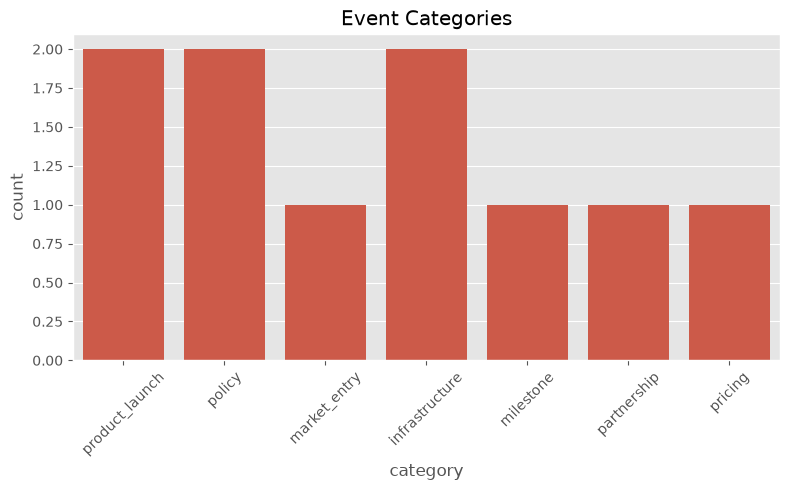

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=events, x="category")
plt.xticks(rotation=45)
plt.title("Event Categories")
plt.tight_layout()
plt.show()

## 6. Impact Link Analysis

In [14]:
print(impact_links["relationship_type"].value_counts())
print(impact_links["impact_direction"].value_counts())
print(impact_links["lag_months"].describe())
print(impact_links["related_indicator"].value_counts())

relationship_type
direct      9
indirect    4
enabling    1
Name: count, dtype: int64
impact_direction
increase    12
decrease     2
Name: count, dtype: int64
count    14.000000
mean      8.428571
std       7.562196
min       1.000000
25%       3.000000
50%       6.000000
75%      12.000000
max      24.000000
Name: lag_months, dtype: float64
related_indicator
USG_P2P_COUNT         3
AFF_DATA_INCOME       3
ACC_OWNERSHIP         2
USG_TELEBIRR_USERS    1
ACC_4G_COV            1
USG_MPESA_USERS       1
ACC_MM_ACCOUNT        1
GEN_GAP_ACC           1
USG_MPESA_ACTIVE      1
Name: count, dtype: int64


## 7. Event–Impact Relationship

`merge_events_with_impacts()` joins `impact_links` to their parent events via `parent_id` — this same function is reused again in `task3_event_impact_modeling.ipynb`, so the join logic only exists in one place.

In [15]:
event_impact = merge_events_with_impacts(events, impact_links)
event_impact.head()

,record_id_impact,parent_id,record_type,category_impact,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date_impact,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes_impact,record_id_event,category_event,observation_date_event,notes_event
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years,EVT_0001,product_launch,2021-05-17,NaN
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition,EVT_0001,product_launch,2021-05-17,NaN
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel,EVT_0001,product_launch,2021-05-17,NaN
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition,EVT_0002,market_entry,2022-08-01,NaN
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices,EVT_0002,market_entry,2022-08-01,NaN


## 8. Data Quality Assessment

`assess_data_quality()` returns missing-value %, duplicate count, and record-type counts as a dict — this is directly unit-tested in `tests/test_data_loader.py::test_assess_data_quality_reports_expected_keys`.

In [16]:
quality = assess_data_quality(df)
print("Rows:", quality["n_rows"])
print("Duplicate rows:", quality["n_duplicates"])
print("Record type counts:", quality["record_type_counts"])
pd.Series(quality["missing_pct_by_column"]).sort_values(ascending=False).head(15)

Rows: 43
Duplicate rows: 0
Record type counts: {'observation': 30, 'event': 10, 'target': 3}


lag_months           100.00
region               100.00
impact_estimate      100.00
relationship_type    100.00
evidence_basis       100.00
notes                100.00
related_indicator    100.00
impact_magnitude     100.00
impact_direction     100.00
category              76.74
period_start          76.74
collection_date       76.74
period_end            76.74
value_text            76.74
source_url            27.91
dtype: float64

## 9. Data Enrichment

New observation/event/impact records added for forecasting (documented in
`docs/data_enrichment_log.md` — source, quote, confidence, collector, date,
and rationale for each). This part stays as explicit data (not logic), so
it remains inline rather than moving into `src/`.

In [17]:
new_observations = pd.DataFrame([
    {
        "record_id": "OBS_0031",
        "record_type": "observation",
        "category": None,
        "pillar": "ACCESS",
        "indicator": "Financial Institution Branches per 100,000 Adults",
        "indicator_code": "ACC_BRANCH",
        "indicator_direction": "higher_better",
        "value_numeric": 8.4,
        "value_text": None,
        "value_type": "percentage",
        "unit": "branches",
        "observation_date": "2025-12-31",
        "period_start": "2025-01-01",
        "period_end": "2025-12-31",
        "fiscal_year": 2025,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia",
        "source_type": "regulator",
        "source_url": "https://nbe.gov.et",
        "confidence": "high",
        "collected_by": "Lalise Fufi",
        "collection_date": "2026-07-22",
        "notes": "Branch density added as an Access-pillar enabler variable.",
    }
])

new_events = pd.DataFrame([
    {
        "record_id": "EVT_0011",
        "record_type": "event",
        "category": "policy",
        "pillar": None,
        "indicator": None,
        "indicator_code": None,
        "indicator_direction": None,
        "value_numeric": None,
        "value_text": "Digital Financial Services Strategy",
        "value_type": "text",
        "unit": None,
        "observation_date": "2026-01-15",
        "period_start": None,
        "period_end": None,
        "fiscal_year": 2026,
        "gender": "all",
        "location": "national",
        "region": None,
        "source_name": "National Bank of Ethiopia",
        "source_type": "policy",
        "source_url": None,
        "confidence": "high",
        "collected_by": "Lalise Fufi",
        "collection_date": "2026-07-22",
        "notes": "New national digital financial services strategy launch.",
    }
])

new_impacts = pd.DataFrame([
    {
        "record_id": "IMP_0015",
        "parent_id": "EVT_0011",
        "record_type": "impact_link",
        "category": None,
        "pillar": "ACCESS",
        "indicator": "Strategy effect on Account Ownership",
        "related_indicator": "ACC_OWNERSHIP",
        "impact_direction": "positive",
        "value_numeric": 10,
        "impact_magnitude": 10,
        "value_type": "percentage",
        "unit": "%",
        "observation_date": "2026-01-15",
        "lag_months": 12,
        "confidence": "medium",
        "collected_by": "Lalise Fufi",
        "collection_date": "2026-07-22",
        "evidence_basis": "comparable_country",
        "notes": "Estimated based on comparable national FI-strategy rollouts.",
    }
])

df = pd.concat([df, new_observations, new_events], ignore_index=True)
impact_links = pd.concat([impact_links, new_impacts], ignore_index=True)

print(df.shape)
print(impact_links.shape)

(45, 34)
(15, 35)


## 10. Save Processed Dataset

`save_processed_dataset()` replaces the inline `Path.mkdir()` + two `.to_csv()` calls.

In [18]:
save_processed_dataset(df, impact_links)
print("Enriched datasets saved successfully to data/processed/.")

Enriched datasets saved successfully to data/processed/.


## 11. Corresponding Tests

The logic exercised in this notebook is unit-tested in
`tests/test_data_loader.py`:

- `test_filter_by_record_type_returns_only_matching_rows`
- `test_filter_by_record_type_missing_column_raises`
- `test_get_observations_parses_dates`
- `test_get_events_sorted_by_date`
- `test_get_indicator_series_extracts_correct_indicator`
- `test_get_indicator_series_unknown_indicator_returns_empty`
- `test_assess_data_quality_reports_expected_keys`

Run with:
```bash
pytest tests/test_data_loader.py -v
```